<a href="https://colab.research.google.com/github/harshaesmayil/Face_Recognition/blob/main/Face_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split

data = []
labels = []
img_size = (64, 64) # Standardizing size for speed

# Loop through person folders (s1, s2, etc.)
for folder in sorted(os.listdir(path)):
    folder_path = os.path.join(path, folder)
    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, 0) # Load as grayscale
            if img is not None:
                img = cv2.resize(img, img_size)
                data.append(img.flatten()) # Turn 2D image into 1D row
                labels.append(folder)

X = np.array(data)
y = np.array(labels)

# Splitting data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data Ready! Matrix shape: {X.shape}")
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

✅ Data Ready! Matrix shape: (400, 4096)
Training samples: 320, Testing samples: 80


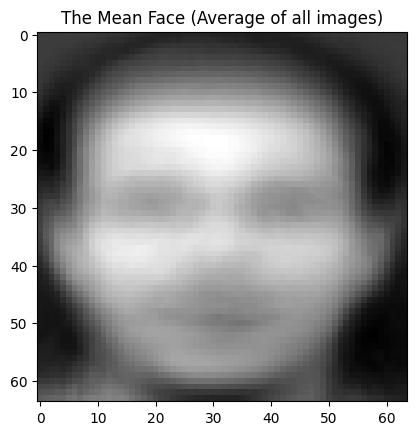

✅ PCA Complete. Dimensionality reduced to 50 features.


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# We reduce the data to 50 principal components
n_components = 50
pca = PCA(n_components=n_components, whiten=True).fit(X_train)

# Projecting the faces into the 'Face Space'
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Show the "Mean Face" for your report
plt.imshow(pca.mean_.reshape(img_size), cmap='gray')
plt.title("The Mean Face (Average of all images)")
plt.show()
print(f"✅ PCA Complete. Dimensionality reduced to {n_components} features.")

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize k-NN with 3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)

# Predict on test data
y_pred = knn.predict(X_test_pca)

# Final Results
accuracy = accuracy_score(y_test, y_pred)
print(f"🚀 Recognition Accuracy: {accuracy * 100:.2f}%")
print("\n--- Detailed Report ---")
print(classification_report(y_test, y_pred))

🚀 Recognition Accuracy: 81.25%

--- Detailed Report ---
              precision    recall  f1-score   support

          s1       1.00      0.33      0.50         3
         s10       0.00      0.00      0.00         1
         s11       1.00      0.50      0.67         2
         s12       1.00      0.75      0.86         4
         s13       0.75      1.00      0.86         3
         s14       1.00      0.67      0.80         3
         s15       0.00      0.00      0.00         0
         s16       1.00      0.50      0.67         6
         s17       0.67      1.00      0.80         2
         s18       0.67      1.00      0.80         2
         s19       0.67      1.00      0.80         2
          s2       1.00      1.00      1.00         3
         s20       1.00      1.00      1.00         2
         s21       1.00      1.00      1.00         1
         s22       0.75      1.00      0.86         3
         s23       1.00      1.00      1.00         2
         s24       0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_